In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (LINEAR-FAMILY)
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization Engine
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error
)

# Serialization & Production
import joblib

# Global Plotting & Warning Configurations
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Universal Linear-Family Enterprise Suite imported successfully.")


✅ Universal Linear-Family Enterprise Suite imported successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ENTERPRISE DATA INGESTION & 3-SECOND RAPID AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"❌ File not found at: {path.resolve()}")
        
    try:
        if path.suffix.lower() in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print("⚠️ UTF-8 decoding failed. Retrying with 'latin-1' encoding...")
        df = pd.read_csv(path, encoding='latin-1')
        
    print("=" * 70)
    print("📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT")
    print("=" * 70)
    print(f"File Source               : {path.name}")
    print(f"Total Observations (Rows) : {df.shape[0]:,}")
    print(f"Total Features (Columns)  : {df.shape[1]}")
    print(f"Numerical Columns         : {len(df.select_dtypes(include=['number']).columns)} cols")
    print(f"Categorical/Text Columns  : {len(df.select_dtypes(exclude=['number']).columns)} cols")
    print(f"Missing Value Cells       : {df.isnull().sum().sum():,} nulls ({df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100:.2f}%)")
    print(f"Memory Footprint in RAM   : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print("=" * 70)
    return df

df = load_and_audit_dataset("data/car_price/car_prediction_data.csv")
display(df.head(5))


📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT
File Source               : car_prediction_data.csv
Total Observations (Rows) : 301
Total Features (Columns)  : 9
Numerical Columns         : 5 cols
Categorical/Text Columns  : 4 cols
Missing Value Cells       : 0 nulls (0.00%)
Memory Footprint in RAM   : 0.03 MB


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
import pandas as pd
import numpy as np

def segregate_features(df, target_col, user_drop_cols=None, cardinality_threshold=0.05):
    if user_drop_cols is None:
        drop_cols = []
    else:
        drop_cols = list(user_drop_cols)
        
    cont_cols = []
    cat_cols = []
    
    candidate_cols = [c for c in df.columns if c != target_col and c not in drop_cols]
    
    for col in candidate_cols:
        col_series = df[col]
        if pd.api.types.is_numeric_dtype(col_series):
            if col_series.nunique() <= 1:
                drop_cols.append(col)
            elif col_series.nunique() <= 5:
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        elif pd.api.types.is_object_dtype(col_series) or pd.api.types.is_string_dtype(col_series):
            unique_ratio = col_series.nunique() / len(df)
            if unique_ratio > cardinality_threshold and col_series.nunique() > 50:
                drop_cols.append(col)
            else:
                cat_cols.append(col)
        else:
            cat_cols.append(col)
            
    print("=" * 70)
    print("🔍 FEATURE SEGREGATION REPORT")
    print("=" * 70)
    print(f"Target Column          : '{target_col}'")
    print(f"Continuous Features    : {len(cont_cols)} cols -> {cont_cols}")
    print(f"Categorical Features   : {len(cat_cols)} cols -> {cat_cols}")
    print(f"Dropped ID / Artifacts : {len(drop_cols)} cols -> {drop_cols}")
    print("=" * 70)
    
    return cont_cols, cat_cols, drop_cols

cont_cols, cat_cols, drop_cols = segregate_features(
    df, 
    target_col='Selling_Price', 
    user_drop_cols=['Car_Name']
)


🔍 FEATURE SEGREGATION REPORT
Target Column          : 'Selling_Price'
Continuous Features    : 3 cols -> ['Year', 'Present_Price', 'Kms_Driven']
Categorical Features   : 4 cols -> ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
Dropped ID / Artifacts : 1 cols -> ['Car_Name']


In [4]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
import pandas as pd

def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE & PURITY REPORT")
    print("=" * 70)
    
    n_dups = df.duplicated().sum()
    if n_dups > 0:
        print(f"⚠️ FOUND {n_dups:,} EXACT DUPLICATE ROWS!")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"✅ Cleaned: {n_dups:,} duplicates removed. New Shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found. Data integrity is clean.")
    print("-" * 70)

    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    
    if len(null_cols) > 0:
        null_report = pd.DataFrame({
            "Missing Count": null_cols,
            "Percentage (%)": (null_cols / len(df) * 100).round(2),
            "Data Type": [df[col].dtype for col in null_cols.index]
        })
        print(f"🚨 FOUND {len(null_cols)} COLUMNS WITH MISSING VALUES:")
        print(null_report.to_string())
    else:
        print("✅ Zero missing values across all features. Dataset is complete.")
    print("=" * 70)
    
    return df

df = audit_and_clean_hygiene(df, drop_duplicates=True)


🧹 STEP 4: DATA HYGIENE & PURITY REPORT
⚠️ FOUND 2 EXACT DUPLICATE ROWS!
✅ Cleaned: 2 duplicates removed. New Shape: (299, 9)
----------------------------------------------------------------------
✅ Zero missing values across all features. Dataset is complete.


In [5]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=False, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Target Safety Guard: Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    stratify_arg = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Guaranteed Clean!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_tr, X_te, y_tr, y_te = perform_zero_leakage_split(
    df, 
    target_col='Selling_Price', 
    drop_cols=drop_cols, 
    apply_log_target=True
)


📈 Target Skewness Normalization: 2.54 -> 0.11 (Bell curve achieved!)
📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 299
Training Matrix (X_tr) : 239 rows × 7 features (80%)
Testing Matrix  (X_te) : 60 rows × 7 features (20%)
Target Missing in y_tr : 0 nulls (Guaranteed Clean!)


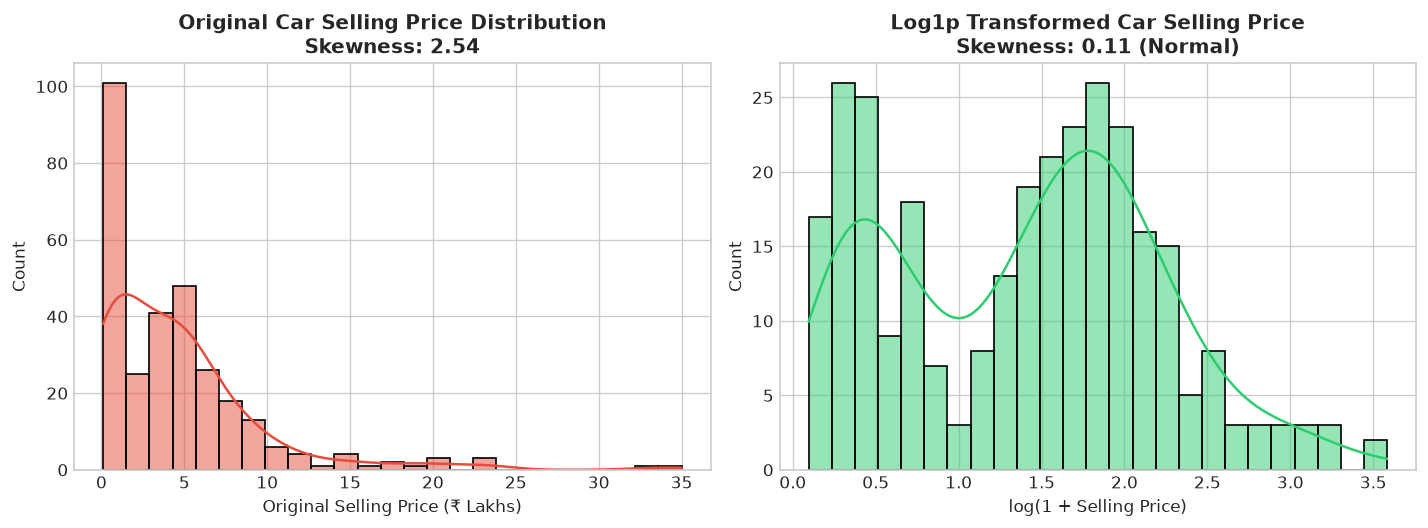

In [6]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def profile_target_distribution(y_original, y_transformed, target_name="Price"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    sns.histplot(y_original, kde=True, ax=axes[0], color='#e74c3c', bins=25)
    axes[0].set_title(f"Original {target_name} Distribution\nSkewness: {y_original.skew():.2f}", fontweight='bold')
    axes[0].set_xlabel("Original Selling Price (₹ Lakhs)")
    
    sns.histplot(y_transformed, kde=True, ax=axes[1], color='#2ecc71', bins=25)
    axes[1].set_title(f"Log1p Transformed {target_name}\nSkewness: {y_transformed.skew():.2f} (Normal)", fontweight='bold')
    axes[1].set_xlabel("log(1 + Selling Price)")
    
    plt.tight_layout()
    plt.show()

profile_target_distribution(df['Selling_Price'], np.log1p(df['Selling_Price']), target_name="Car Selling Price")


In [7]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="None"):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=cat_impute_value)),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, continuous_features),
        ('cat', cat_pipeline, categorical_features)
    ])
    
    return preprocessor

def execute_safe_preprocessing(preprocessor, X_train, X_test, continuous_features, categorical_features):
    X_tr_proc = preprocessor.fit_transform(X_train)
    X_te_proc = preprocessor.transform(X_test)
    
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = continuous_features + cat_encoded_names
    
    print("=" * 70)
    print("⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)")
    print("=" * 70)
    print(f"Continuous Features Processed   : {len(continuous_features)} cols")
    print(f"Categorical Features Processed  : {len(categorical_features)} cols")
    print(f"One-Hot Dummy Features Created  : {len(cat_encoded_names)} cols")
    print(f"Total Model Input Dimensions    : {X_tr_proc.shape[1]} features")
    print(f"X_train Processed Shape         : {X_tr_proc.shape}")
    print(f"X_test Processed Shape          : {X_te_proc.shape}")
    print("=" * 70)
    
    return X_tr_proc, X_te_proc, all_feature_names

continuous_features, categorical_features = cont_cols, cat_cols
X_train, X_test = X_tr, X_te
preprocessor = build_universal_preprocessor(continuous_features, categorical_features)
X_train_final, X_test_final, all_names = execute_safe_preprocessing(
    preprocessor, X_train, X_test, continuous_features, categorical_features
)


⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)
Continuous Features Processed   : 3 cols
Categorical Features Processed  : 4 cols
One-Hot Dummy Features Created  : 5 cols
Total Model Input Dimensions    : 8 features
X_train Processed Shape         : (239, 8)
X_test Processed Shape          : (60, 8)


In [8]:
# ==============================================================================
# 🏆 STEP 8: ELASTICNETCV 2D HYPERPARAMETER TUNING (ALPHA & L1_RATIO GRID)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import KFold

# 1. 2D Search Space: l1_ratio x alphas
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
alphas = np.logspace(-4, 1, 100)

# 2. 5-Fold Cross-Validation on Training Data ONLY (Zero Leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=kf,
    max_iter=10000,
    tol=1e-3,
    random_state=42
)
elastic_cv.fit(X_train_final, y_tr)

best_alpha = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_

# 3. Fit Best ElasticNet Model
best_elastic = ElasticNet(
    alpha=best_alpha, 
    l1_ratio=best_l1_ratio, 
    max_iter=10000, 
    tol=1e-3, 
    random_state=42
)
best_elastic.fit(X_train_final, y_tr)

# 4. Diagnostic Summary Report
zero_feats = np.sum(best_elastic.coef_ == 0)
total_feats = len(best_elastic.coef_)
active_feats = total_feats - zero_feats

print("=" * 70)
print("🏆 STEP 8: ELASTICNETCV 2D HYPERPARAMETER TUNING REPORT")
print("=" * 70)
print(f"Optimal Alpha (Total Penalty) : {best_alpha:.5f}")
print(f"Optimal L1 Ratio (L1 vs L2)   : {best_l1_ratio:.2f}")
print(f"   • L1 (Lasso Sparsity Part) : {best_l1_ratio * 100:.0f}%")
print(f"   • L2 (Ridge Grouping Part) : {(1 - best_l1_ratio) * 100:.0f}%")
print(f"Total Input Features          : {total_feats} features")
print(f"Active Features Retained      : {active_feats} features (Non-zero)")
print(f"Useless Features Eliminated   : {zero_feats} features ({zero_feats/total_feats*100:.1f}% Sparsity!)")
print(f"Model Intercept (log scale)   : {best_elastic.intercept_:.4f}")
print("=" * 70)


🏆 STEP 8: ELASTICNETCV 2D HYPERPARAMETER TUNING REPORT
Optimal Alpha (Total Penalty) : 0.00586
Optimal L1 Ratio (L1 vs L2)   : 0.99
   • L1 (Lasso Sparsity Part) : 99%
   • L2 (Ridge Grouping Part) : 1%
Total Input Features          : 8 features
Active Features Retained      : 5 features (Non-zero)
Useless Features Eliminated   : 3 features (37.5% Sparsity!)
Model Intercept (log scale)   : 1.7556


In [9]:
# ==============================================================================
# ⚔️ STEP 9: THE QUAD BATTLE: OLS VS. RIDGE VS. LASSO VS. ELASTICNET
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Optimal alphas from earlier Car Price projects
ridge_alpha = 5.6899
lasso_alpha = 0.00010

# 1. Fit All 4 Models
ols_m = LinearRegression().fit(X_train_final, y_tr)
ridge_m = Ridge(alpha=ridge_alpha, random_state=42).fit(X_train_final, y_tr)
lasso_m = Lasso(alpha=lasso_alpha, max_iter=10000, tol=1e-3, random_state=42).fit(X_train_final, y_tr)
elastic_m = best_elastic

# 2. Predict on Test Set (Log Scale)
ols_pred_log = ols_m.predict(X_test_final)
ridge_pred_log = ridge_m.predict(X_test_final)
lasso_pred_log = lasso_m.predict(X_test_final)
elastic_pred_log = elastic_m.predict(X_test_final)

# 3. Invert Log Scale back to Real ₹ Lakhs (np.expm1)
y_test_real = np.expm1(y_te)
ols_pred_real = np.expm1(ols_pred_log)
ridge_pred_real = np.expm1(ridge_pred_log)
lasso_pred_real = np.expm1(lasso_pred_log)
elastic_pred_real = np.expm1(elastic_pred_log)

# 4. Compile Metrics Table
models = {
    'OLS Linear Regression': (ols_m, ols_pred_log, ols_pred_real),
    'Ridge Regression (L2)': (ridge_m, ridge_pred_log, ridge_pred_real),
    'Lasso Regression (L1)': (lasso_m, lasso_pred_log, lasso_pred_real),
    'ElasticNet (L1 + L2)':  (elastic_m, elastic_pred_log, elastic_pred_real)
}

rows = []
for name, (mod, p_log, p_real) in models.items():
    tr_r2 = r2_score(y_tr, mod.predict(X_train_final))
    te_r2 = r2_score(y_te, p_log)
    rmse = root_mean_squared_error(y_test_real, p_real)
    mae = mean_absolute_error(y_test_real, p_real)
    n_active = np.sum(mod.coef_ != 0)
    total_f = len(mod.coef_)
    
    rows.append({
        'Model Name': name,
        'Train R²': f"{tr_r2*100:.2f}%",
        'Test R²': f"{te_r2*100:.2f}%",
        'Real RMSE': f"₹{rmse:,.2f} L",
        'Real MAE': f"₹{mae:,.2f} L",
        'Active Features': f"{n_active} / {total_f}",
        'Sparsity (%)': f"{(total_f - n_active) / total_f * 100:.1f}%"
    })

quad_df = pd.DataFrame(rows)

print("=" * 85)
print("🏆 THE QUAD BATTLE SHOWDOWN: OLS VS. RIDGE VS. LASSO VS. ELASTICNET")
print("=" * 85)
print(quad_df.to_string(index=False))
print("=" * 85)


🏆 THE QUAD BATTLE SHOWDOWN: OLS VS. RIDGE VS. LASSO VS. ELASTICNET
           Model Name Train R² Test R² Real RMSE Real MAE Active Features Sparsity (%)
OLS Linear Regression   90.49%  94.11%   ₹1.57 L  ₹0.90 L           8 / 8         0.0%
Ridge Regression (L2)   90.14%  93.51%   ₹1.63 L  ₹0.96 L           8 / 8         0.0%
Lasso Regression (L1)   90.48%  94.09%   ₹1.57 L  ₹0.91 L           8 / 8         0.0%
 ElasticNet (L1 + L2)   90.35%  94.09%   ₹1.67 L  ₹0.94 L           5 / 8        37.5%


⚖️ ELASTICNET FEATURE SELECTION & GROUPING REPORT
Total Features Evaluated     : 8
✅ Surviving Features (Active) : 5 features
❌ Eliminated Noise Features  : 3 features
   Eliminated Feature List    : ['Kms_Driven', 'Fuel_Type_Petrol', 'Owner_1']
🔍 ALL FEATURES WEIGHTS COMPARISON TABLE:
               Feature  OLS_Weight  Ridge_Weight  Lasso_Weight  ElasticNet_Weight
         Present_Price    0.345792      0.362757      0.346067           0.359605
                  Year    0.183573      0.189039      0.184068           0.184412
      Fuel_Type_Diesel    0.340948      0.116116      0.287855           0.158395
            Kms_Driven   -0.001192      0.006738     -0.000816           0.000000
      Fuel_Type_Petrol    0.143815     -0.082607      0.091411          -0.000000
               Owner_1   -0.073956     -0.054384     -0.069986          -0.000000
   Transmission_Manual   -0.129672     -0.102595     -0.128911          -0.076594
Seller_Type_Individual   -0.922459     -0.816160     -0.9

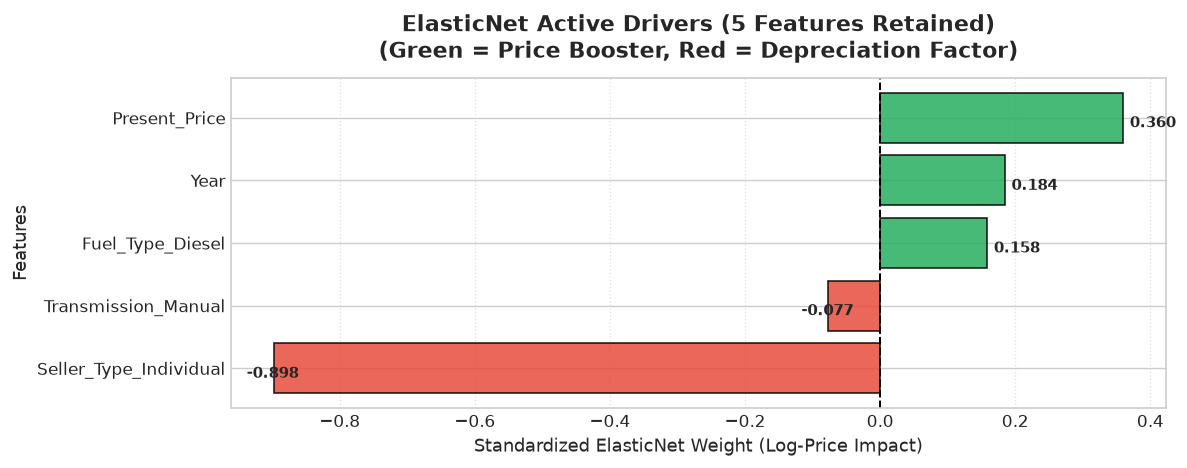

In [10]:
# ==============================================================================
# 📊 STEP 10: ELASTICNET FEATURE IMPORTANCE & GROUPING EFFECT DASHBOARD
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Feature Weights DataFrame Banayein
weights_df = pd.DataFrame({
    'Feature': all_names,
    'OLS_Weight': ols_m.coef_,
    'Ridge_Weight': ridge_m.coef_,
    'Lasso_Weight': lasso_m.coef_,
    'ElasticNet_Weight': best_elastic.coef_
})

# 2. Divide into Survivors vs. Eliminated
survivors = weights_df[weights_df['ElasticNet_Weight'] != 0].sort_values(by='ElasticNet_Weight', ascending=True)
eliminated = weights_df[weights_df['ElasticNet_Weight'] == 0]['Feature'].tolist()

print("=" * 75)
print("⚖️ ELASTICNET FEATURE SELECTION & GROUPING REPORT")
print("=" * 75)
print(f"Total Features Evaluated     : {len(all_names)}")
print(f"✅ Surviving Features (Active) : {len(survivors)} features")
print(f"❌ Eliminated Noise Features  : {len(eliminated)} features")
print(f"   Eliminated Feature List    : {eliminated}")
print("=" * 75)

# 3. Horizontal Bar Chart (Active Features)
if len(survivors) > 0:
    plt.figure(figsize=(10, max(4, len(survivors) * 0.55)))
    colors = ['#27ae60' if w > 0 else '#e74c3c' for w in survivors['ElasticNet_Weight']]

    bars = plt.barh(
        survivors['Feature'], 
        survivors['ElasticNet_Weight'], 
        color=colors, 
        edgecolor='black', 
        alpha=0.85
    )
    plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
    plt.title(
        f'ElasticNet Active Drivers ({len(survivors)} Features Retained)\n(Green = Price Booster, Red = Depreciation Factor)', 
        fontsize=13, 
        fontweight='bold',
        pad=12
    )
    plt.xlabel('Standardized ElasticNet Weight (Log-Price Impact)', fontsize=11)
    plt.ylabel('Features', fontsize=11)
    plt.grid(axis='x', linestyle=':', alpha=0.6)

    for bar in bars:
        w = bar.get_width()
        offset = 0.01 if w >= 0 else -0.04
        plt.text(
            w + offset, 
            bar.get_y() + 0.25, 
            f'{w:.3f}', 
            fontsize=9, 
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

# 4. Summary Table of All Features
print("🔍 ALL FEATURES WEIGHTS COMPARISON TABLE:")
print("=" * 75)
print(weights_df.sort_values(by='ElasticNet_Weight', ascending=False).to_string(index=False))
print("=" * 75)


In [11]:
# ==============================================================================
# 🏭 STEP 11: PRODUCTION PIPELINE SERIALIZATION & LIVE INFERENCE TEST
# ==============================================================================
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

# 1. Master End-to-End Production Pipeline banayein
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('elasticnet', best_elastic)
])

# 2. Fit strictly on Raw X_tr and Log-transformed Target y_tr
production_pipeline.fit(X_tr, y_tr)

# 3. Model ko Disk par save karein (.joblib)
model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'car_price_elasticnet_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print("=" * 70)
print("🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY")
print("=" * 70)
print(f"✅ Full Production Pipeline Saved: {model_path}")
print(f"   Artifact File Size           : {model_path.stat().st_size / 1024:.2f} KB")
print("=" * 70)

# 4. Live Smoke Test: Ek Unseen Gaadi par Live Inference
loaded_pipeline = joblib.load(model_path)
sample_car = X_te.iloc[0:1]

# Model se predict karein (Log scale -> Real ₹ Lakhs mein invert)
pred_log_price = loaded_pipeline.predict(sample_car)[0]
predicted_lakhs = np.expm1(pred_log_price)
actual_lakhs = np.expm1(y_te.iloc[0])

print("\n🧪 LIVE REAL-TIME CAR PRICE VALUATION TEST (1 VEHICLE):")
print("-" * 65)
for col in sample_car.columns:
    print(f"   • {col:<20}: {sample_car[col].values[0]}")
print("-" * 65)
print(f"   🎯 Model Predicted Price : ₹{predicted_lakhs:.2f} Lakhs")
print(f"   🏷️ Actual Selling Price  : ₹{actual_lakhs:.2f} Lakhs")
diff = abs(predicted_lakhs - actual_lakhs)
print(f"   📊 Valuation Difference  : ₹{diff:.2f} Lakhs ({diff/actual_lakhs*100:.1f}%)")
print("=" * 70)


🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY
✅ Full Production Pipeline Saved: production_models/car_price_elasticnet_pipeline.joblib
   Artifact File Size           : 4.97 KB

🧪 LIVE REAL-TIME CAR PRICE VALUATION TEST (1 VEHICLE):
-----------------------------------------------------------------
   • Year                : 2016
   • Present_Price       : 11.8
   • Kms_Driven          : 9010
   • Fuel_Type           : Petrol
   • Seller_Type         : Dealer
   • Transmission        : Manual
   • Owner               : 0
-----------------------------------------------------------------
   🎯 Model Predicted Price : ₹6.44 Lakhs
   🏷️ Actual Selling Price  : ₹8.99 Lakhs
   📊 Valuation Difference  : ₹2.55 Lakhs (28.3%)
